In [86]:
from __future__ import annotations

import os
import itertools
import math
import random

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

from path_clustering import (
    extract_clusters,
    _compute_cluster_weights,
    _build_cluster_graph,
    _boundary_vertices,
    order_clusters,
    order_within_cluster,
)
from rank_width_sa import _relabel_to_int, _full_evaluate
from lib.tableau import stabTableau
from lib.generate_graph import GraphstateGenerator

In [87]:
def repeater_graph():
    n = 12
    nodes = np.arange(1, n+1, 1)
    #edges = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(2,4),(2,6),(2,8),(2,10),(2,12),(4,6),(4,8),(4,10),(4,12),
    #         (6,8),(6,10),(6,12),(8,10),(8,12),(10,12)]
    edges = [(1,7),(2,8),(3,9),(4,10),(5,11),(6,12),(7,8),(7,9),(7,10),(7,11),(7,12),(8,9),(8,10),(8,11),(8,12),
             (9,10),(9,11),(9,12),(10,11),(10,12),(11,12)]
    return edges

[[0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 1 1 1 1]
 [0 1 0 0 0 0 1 0 1 1 1 1]
 [0 0 1 0 0 0 1 1 0 1 1 1]
 [0 0 0 1 0 0 1 1 1 0 1 1]
 [0 0 0 0 1 0 1 1 1 1 0 1]
 [0 0 0 0 0 1 1 1 1 1 1 0]]


[]

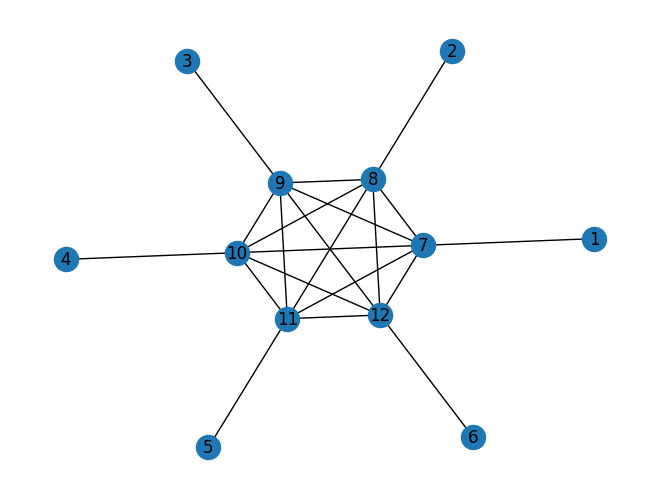

In [88]:
G = nx.Graph()
G.add_edges_from(repeater_graph())

n = G.number_of_nodes()

adj = nx.adjacency_matrix(G,nodelist=list(range(1,n+1))).toarray().astype(np.uint8)
print(adj)
nx.draw(G,pos=nx.kamada_kawai_layout(G),with_labels=True)
plt.plot()

[1. 2. 3. 4. 5. 6. 5. 4. 3. 2. 1.] [0, 0, 0, 0, 0, 6, 5, 4, 3, 2, 1]


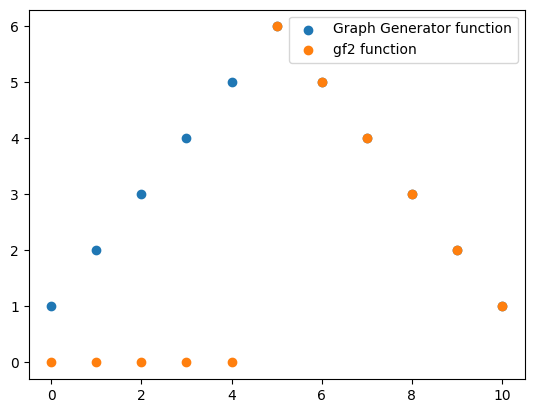

In [83]:
temp_tableau = stabTableau.get_tableau_from_adj(adj)
heights = temp_tableau.h0[1:-1]
global_ordering = list(range(n))
heights_old = []
for cut in range(n-1):
    left = global_ordering[:cut+1]
    right = global_ordering[cut+1:]
    sub = adj[np.ix_(left,right)]
    from rank_width_sa import gf2_rank
    heights_old.append(gf2_rank(sub))

print(heights,heights_old)

plt.scatter(range(n-1),heights, label="Graph Generator function")
plt.scatter(range(n-1),heights_old, label="gf2 function")
plt.legend()
plt.show()